In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
def combine_subjects(df, codes_df):

    combined_df_data=[]

    for i, row in codes_df.iterrows():

        same_sub_mrns=[]

        for col in codes_df.columns:
            if col=='IncomingSite' or col=='Status':
                continue
            if np.isnan(row[col]):
                continue
            
            if int(row[col]) in df['MRN'].values and int(row[col]) not in same_sub_mrns:
                same_sub_mrns.append(int(row[col]))

        same_sub_df=df[df['MRN'].isin(same_sub_mrns)]

        if len(same_sub_mrns)==1:
            combined_df_data.append(same_sub_df.iloc[0].tolist()+[', '.join(str(mrn) for mrn in same_sub_mrns)])

        elif len(same_sub_mrns)>1:
            combined_row=[row['IncomingId']]
            for col in same_sub_df.columns[1:]:
                combined_row.append(same_sub_df[col].max())
            combined_df_data.append(combined_row+[', '.join(str(mrn) for mrn in same_sub_mrns)])


    out=pd.DataFrame(combined_df_data, columns=df.columns.tolist()+['other_matched_mrns'])
    out[df.columns.tolist()]=out[df.columns.tolist()].astype(int)

    return out


def accuracy(conf_matrix):
    
    total_questions=sum([sum(row) for row in conf_matrix])
    good_answers=0
    for i in range(len(conf_matrix)):
        good_answers += conf_matrix[i][i]
    accuracy=good_answers/total_questions
    return total_questions, accuracy

def sensitivity(conf_matrix, yes_col=2):
    total=sum(conf_matrix[yes_col])
    true_positives=conf_matrix[yes_col][yes_col]
    return true_positives/total

def specificity(conf_matrix, no_col=1):
    total=sum(conf_matrix[no_col])
    true_negatives=conf_matrix[no_col][no_col]
    return true_negatives/total

def precision(conf_matrix, yes_col=2):
    true_positives=conf_matrix[yes_col][yes_col]
    predicted_positives=sum([conf_matrix[i][yes_col] for i in range(len(conf_matrix))])
    return true_positives/predicted_positives

In [ ]:
ccas_questions=list(json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))['ccas'].keys())
domain_question_dict=json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))['ccas_domains']

ai=pd.read_csv("/Users/rm026/Documents/schmahmann/schmahmann_ccas_domains/master_list.csv")

ai=ai[['MRN']+list(domain_question_dict.keys())]
ai.rename(columns=domain_question_dict, inplace=True)
ai['affect_count']=sum([ai[column]-1 for column in ai.columns if 'affect' in column])
ai['affect']=1+1*(ai['affect_count']>1)

gt=pd.read_csv("/Users/rm026/Documents/schmahmann/ground_truth_master_list_ccas_combined.csv")

gt['language']=gt[['semantic fluency', 'phonemic fluency']].max(axis=1)
gt['executive']=gt[['category switching', 'digit span','go-no go']].max(axis=1)
gt['memory']=gt['verbal registration']
gt['visuospatial']=gt[['cube draw', 'cube copy']].max(axis=1)

merged=pd.merge(ai,gt,on='MRN',suffixes=('_ai','_gt'))
merged

,MRN,language_ai,executive_ai,memory_ai,visuospatial_ai,affect_emotion,affect_sensory,affect_paranoia,affect_blunted,affect_irritability,...,cube draw,cube copy,similarities,go-no go,affect_gt,other_matched_mrns,language_gt,executive_gt,memory_gt,visuospatial_gt
0,956657,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,2,"956657, 18287649, 100355601",0,0,1,0
1,1175258,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,1,1175258,0,0,0,0
2,1315351,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,1,"1315351, 9241085",1,0,1,0
3,1355923,1.0,2.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,...,0,0,0,0,1,"1355923, 11077978",0,0,0,0
4,1798457,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,...,0,0,0,0,2,"1798457, 11951464, 1064237, 100304904, 7665334",0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,8231339,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,0,0,0,0,1,8231339,0,0,0,0
81,8254224,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,1,8254224,0,0,0,0
82,8344492,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,0,0,0,0,1,8344492,0,0,0,0
83,8346686,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,...,0,0,0,0,1,8346686,0,0,0,0


In [6]:
domain_questions=['language','executive','memory','visuospatial','affect']

In [9]:
conf_matrix=[[0,0,0],
             [0,0,0],
             [0,0,0]]
for q in domain_questions:
    for truth, pred in zip(merged[q+'_gt'],merged[q+'_ai']):
        if type(pred)==str:
            print(f"Skipping string prediction: {pred}")
            continue
        conf_matrix[int(truth)][int(pred)]+=1
conf_matrix=np.array(conf_matrix)

In [10]:
conf_df=pd.DataFrame(conf_matrix,columns=['Predict unknown','Predict no','Predict yes'],index=['Truth unknown','Truth no','Truth yes'])
conf_df

,Predict unknown,Predict no,Predict yes
Truth unknown,45,148,48
Truth no,0,73,40
Truth yes,0,13,58


In [11]:
accuracy(conf_matrix)

(np.int64(425), np.float64(0.41411764705882353))

In [ ]:
def combine_no_unknown(conf):
    output=np.array([conf[0]+conf[1], conf[2]])
    output=np.array([output[:,0]+output[:,1], output[:,2]]) 
    return output

In [36]:
merge_no_unk=np.array([conf_matrix[0]+conf_matrix[1], conf_matrix[2]])
merge_no_unk=np.array([merge_no_unk[:,0]+merge_no_unk[:,1], merge_no_unk[:,2]])
merge_no_unk, accuracy(merge_no_unk)

(array([[266,  13],
        [ 88,  58]]),
 (np.int64(425), np.float64(0.7623529411764706)))

In [12]:
errors_of_omission=np.array([conf_matrix[0]+conf_matrix[1], conf_matrix[2]])
errors_of_omission=np.array([errors_of_omission[:,0]+errors_of_omission[:,1], errors_of_omission[:,2]])
# errors_of_omission['Pred no/unknown']=errors_of_omission['Predict unknown']+errors_of_omission['Predict no']
errors_of_omission, accuracy(errors_of_omission)

(array([[266,  13],
        [ 88,  58]]),
 (np.int64(425), np.float64(0.7623529411764706)))

In [13]:
ignoring_unknowns_accuracy=accuracy(conf_matrix[1:,1:])
ignoring_unknowns_accuracy

(np.int64(184), np.float64(0.7119565217391305))

In [14]:
confs={}
blank_matrix=[[0,0,0],
             [0,0,0],
             [0,0,0]]
for q in domain_questions:
    q_matrix=blank_matrix.copy()
    for truth, pred in zip(merged[q+'_gt'],merged[q+'_ai']):
        if type(pred)==str:
            print(f"Skipping string prediction: {pred}")
            continue
        q_matrix[int(truth)][int(pred)]+=1
    confs[q]=np.array(q_matrix)
resultsdf=pd.DataFrame.from_dict({q:np.round(accuracy(confs[q])[1],3) for q in domain_questions}, orient='index', columns=['accuracy'])
resultsdf['specificity']=[np.round(specificity(confs[q]),3) for q in domain_questions]
resultsdf['sensitivity']=[np.round(sensitivity(confs[q]),3) for q in domain_questions]
resultsdf['precision']=[np.round(precision(confs[q]),3) for q in domain_questions]
resultsdf.reset_index(inplace=True, names='question')
resultsdf


,question,accuracy,specificity,sensitivity,precision
0,language,0.212,0.400,0.800,0.364
1,executive,0.229,0.440,0.900,0.360
2,memory,0.239,0.491,0.886,0.313
3,visuospatial,0.326,0.500,0.902,0.325
4,affect,0.414,0.646,0.817,0.397


In [16]:
score_names=['accuracy','sensitivity','specificity','precision']

def plot_scores(df, yrange=(.7,1.03),title='Schmahmann CCAS evaluation by question',
                output_file=f'/Users/rm026/Documents/schmahmann/stats_by_question.png'):
    
    colors=['Tomato', 'blue', 'green','purple','orange']

    plt.figure(figsize=(6,4))
    markers=['o','s','^', 'D']
    for i, score in enumerate(score_names):
        plt.plot(df['question'].str.title(), df[score], marker=markers[i], color=colors[i])

    plt.title(title)
    plt.ylim(yrange)
    plt.xticks(rotation=45, ha='right')
    plt.legend([score.capitalize() for score in score_names])
    plt.savefig(output_file, bbox_inches='tight')
    plt.show()

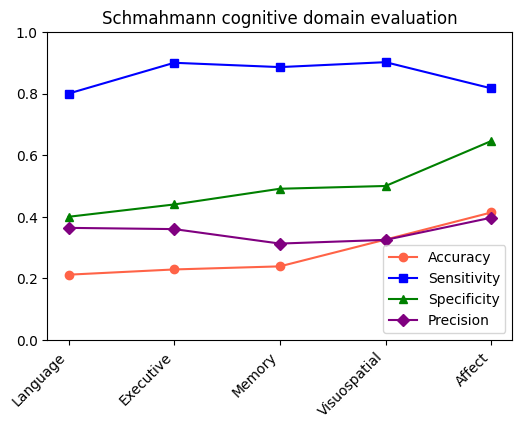

In [28]:
plot_scores(resultsdf,
            yrange=(0,1),
            title='Schmahmann cognitive domain evaluation',
            output_file=f'/Users/rm026/Documents/schmahmann/plots/stats_by_domain_question.png')

In [19]:
results_unk_removed=pd.DataFrame.from_dict({q:np.round(accuracy(confs[q][1:,1:])[1],3) for q in domain_questions}, orient='index', columns=['accuracy'])
results_unk_removed['specificity']=[np.round(specificity(confs[q][1:,1:], no_col=0),3) for q in domain_questions]
results_unk_removed['sensitivity']=[np.round(sensitivity(confs[q][1:,1:],yes_col=1),3) for q in domain_questions]
results_unk_removed['precision']=[np.round(precision(confs[q][1:,1:],yes_col=1),3) for q in domain_questions]
results_unk_removed.reset_index(inplace=True, names='question')
results_unk_removed

,question,accuracy,specificity,sensitivity,precision
0,language,0.600,0.400,0.800,0.571
1,executive,0.691,0.440,0.900,0.659
2,memory,0.648,0.491,0.886,0.534
3,visuospatial,0.667,0.500,0.902,0.561
4,affect,0.712,0.646,0.817,0.592


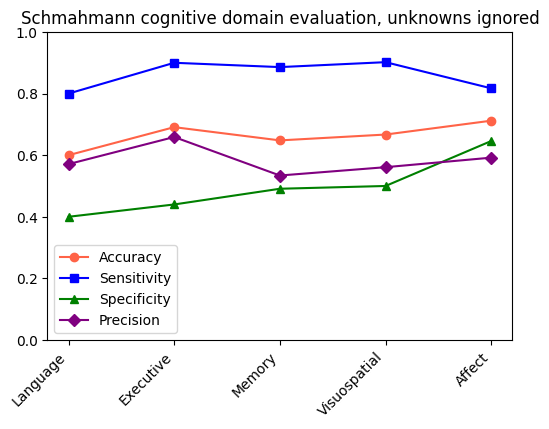

In [27]:
plot_scores(results_unk_removed, yrange=(0,1),
            title='Schmahmann cognitive domain evaluation, unknowns ignored', 
            output_file=f'/Users/rm026/Documents/schmahmann/plots/stats_by_domain_question_unk_removed.png')

In [22]:
def boxplot(data,
              labels,
              title=None,
              filename='raincloud_plot.png',
              ylim=(-10,10),):
    
    fig, ax = plt.subplots(figsize=(6,4))
    
    # Create a list of colors for the boxplots based on the number of features you have
    boxplots_colors = ['darkred', 'blue', 'green','purple','orange']
    
    # Boxplot data
    bp = ax.boxplot(data, 
                    # notch=True,
                    patch_artist = True, 
                    vert = True,
                    showfliers=False,
                   medianprops={'linewidth':1.5},
                #    whiskerprops={'linewidth':2},
                   capprops={'linewidth':2}
                   )
    
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], boxplots_colors):
        patch.set_facecolor(color)
        # patch.set_alpha(0.8)
    
    # Create a list of colors for the scatter plots based on the number of features you have
    scatter_colors = ['tomato', 'teal', 'lime', 'violet', 'tangerine']
    
    # Scatterplot data
    for idx, features in enumerate(data):
        # Add jitter effect so the features do not overlap on the y-axis
        y = np.full(len(features), idx + .65)
        idxs = np.arange(len(y))
        out = y.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
        y = out
        plt.scatter(y, features, c=scatter_colors[idx], edgecolors='black', alpha=.8)
    
    plt.xticks(np.arange(1,len(labels)+1,1), labels)  # Set text labels.
    # plt.ylabel('Damage Score', size='medium')
    plt.title(title)
    plt.ylim(ylim)
    plt.savefig(filename,bbox_inches='tight')
    plt.show()

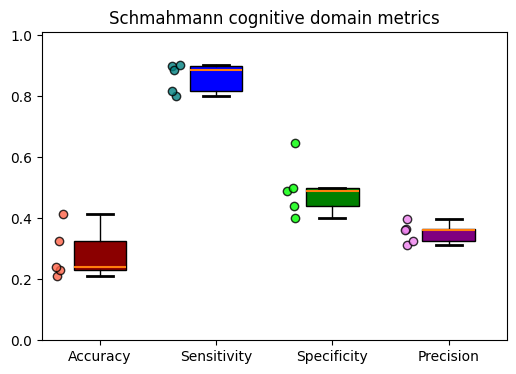

In [26]:
boxplot([resultsdf[score] for score in score_names], 
        labels=[score.title() for score in score_names], 
        title='Schmahmann cognitive domain metrics',
        filename='/Users/rm026/Documents/schmahmann/schmahmann_domain_metrics_boxplot.png', 
        ylim=(0,1.01))